In [1]:
import os
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

IMG_SIZE=128

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
val_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Scale to [-1, 1]
    ])
aug_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Scale to [-1, 1]
    ])


def get_dataloaders(data_dir, batch_size=32, shuffle=True, transform=val_transform):
    # standard preprocessing for VAEs

    # Load the full dataset
    full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
    
    # Filter for only Cats (label 0) and Dogs (label 1) 
    # AFHQ structure is usually: 0:cat, 1:dog, 2:wild
    indices = [i for i, (_, label) in enumerate(full_dataset.samples) if label in [0, 1]]
    cat_dog_dataset = Subset(full_dataset, indices)
    
    loader = DataLoader(cat_dog_dataset, batch_size=batch_size, shuffle=shuffle)
    return loader, full_dataset.classes

def visualize_transformation(model, dataloader, device):
    model.eval()
    
    # 1. Get a batch of real data
    images, labels = next(iter(dataloader))
    images, labels = images.to(device), labels.to(device)
    
    # 2. Pick only the cats (Label 0) from the batch
    cat_indices = (labels == 0).nonzero(as_tuple=True)[0]
    if len(cat_indices) == 0: 
        print("No cats found in this batch to transform.")
        return
    
    # Take top 4 cats
    cats = images[cat_indices[:4]]
    n_samples = len(cats)
    
    # Create the labels we need
    cat_labels = torch.zeros(n_samples, dtype=torch.long).to(device)
    dog_labels = torch.ones(n_samples, dtype=torch.long).to(device) # Target Label
    
    with torch.no_grad():
        # --- STEP A: Pixel -> Latent (Frozen VAE) ---
        # We must compress the real cat images so your model can read them
        posterior = model.pretrained_vae.encode(cats).latent_dist
        cat_latents = posterior.sample() * 0.18215
        
        # --- STEP B: Encode (Your Model) ---
        # Your model takes the compressed cat + cat label -> finds the "content vector" (mu)
        mu, _ = model.encode(cat_latents, cat_labels)
        
        # --- STEP C: Decode (Your Model) ---
        # We assume the content is the same, but we swap the label to "Dog"
        # Your model predicts what the DOG Latents should look like
        transformed_latents = model.decode(mu, dog_labels)
        
        # --- STEP D: Latent -> Pixel (Frozen VAE) ---
        # Unscale and decode to see the final image
        transformed_latents = transformed_latents / 0.18215
        transformed_dogs = model.pretrained_vae.decode(transformed_latents).sample

    # --- Plotting ---
    # Move to CPU for plotting
    cats = cats.cpu()
    transformed_dogs = transformed_dogs.cpu()
    
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    
    # Handle cases where we found fewer than 4 cats
    for i in range(4):
        if i < n_samples:
            # 1. Show Original Cat
            # Denormalize: [-1, 1] -> [0, 1]
            orig_img = (cats[i].permute(1, 2, 0) + 1) / 2
            axes[0, i].imshow(orig_img.clamp(0, 1))
            axes[0, i].set_title("Original Cat")
            axes[0, i].axis('off')
            
            # 2. Show Transformed Dog
            # Denormalize: [-1, 1] -> [0, 1]
            trans_img = (transformed_dogs[i].permute(1, 2, 0) + 1) / 2
            axes[1, i].imshow(trans_img.clamp(0, 1))
            axes[1, i].set_title("Transformed Dog")
            axes[1, i].axis('off')
        else:
            # Hide empty axes if we found fewer than 4 cats
            axes[0, i].axis('off')
            axes[1, i].axis('off')
            
    plt.tight_layout()
    plt.show()

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def show_batch(dataloader, classes):
    images, labels = next(iter(dataloader))
    
    # Un-normalize for visualization
    images = images * 0.5 + 0.5 
    
    plt.figure(figsize=(12, 6))
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(np.transpose(images[i].numpy(), (1, 2, 0)))
        plt.title(f"Label: {classes[labels[i]]}")
        plt.axis('off')
    plt.show()

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from diffusers import AutoencoderKL
class ResidualBlock(nn.Module):
    """
    A simple ResNet block to keep gradients flowing.
    """
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(channels),
            nn.SiLU(),
            nn.Conv2d(channels, channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(channels),
        )
    def forward(self, x):
        return x + self.block(x)
class LatentCVAE(nn.Module):
    def __init__(self, latent_dim=128, num_classes=2):
        super().__init__()
        self.pretrained_vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)
        self.pretrained_vae.eval()
        for param in self.pretrained_vae.parameters():
            param.requires_grad = False
        self.dropout = nn.Dropout(0.2) # 20% dropout
        # Input channels = 4 (Standard for SD VAE) + 1 (Label) = 5
        self.encoder = nn.Sequential(
            nn.Conv2d(5, 128, 3, 1, 1), nn.ReLU(),
            nn.Conv2d(128, 256, 3, 2, 1), nn.ReLU(),
            nn.Flatten()
        )
        
        # Calculate flatten size roughly (assuming 256px input -> 32px latent -> 16px after conv)
        # You might need to adjust this depending on your image size!
        # For 64x64 input image -> 8x8 latent -> 4x4 after stride 2 -> 128*4*4 = 2048
        self.flat_size = 256 * 8 * 8 
        
        self.fc_mu = nn.Linear(self.flat_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_size, latent_dim)
        self.decoder_input = nn.Linear(latent_dim + 64, self.flat_size)
        
        self.label_emb = nn.Embedding(num_classes, 64)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(),
            # Output must be 4 channels to match VAE latent space
            nn.Conv2d(128, 4, 3, 1, 1) 
        )

    def encode(self, x, y):
        # Expand label to match spatial dims of x (which is the LATENT x, not image x)
        y_expanded = y.view(-1, 1, 1, 1).expand(-1, 1, x.size(2), x.size(3))
        x = torch.cat([x, y_expanded], dim=1)
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def decode(self, z, y):
        y_emb = self.label_emb(y)
        z = torch.cat([z, y_emb], dim=1)
        h = self.decoder_input(z)
        h = h.view(-1, 256, 8, 8) # Reshape back to spatial
        return self.decoder(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, y), mu, logvar


/home/teo/kaggle/csiro/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


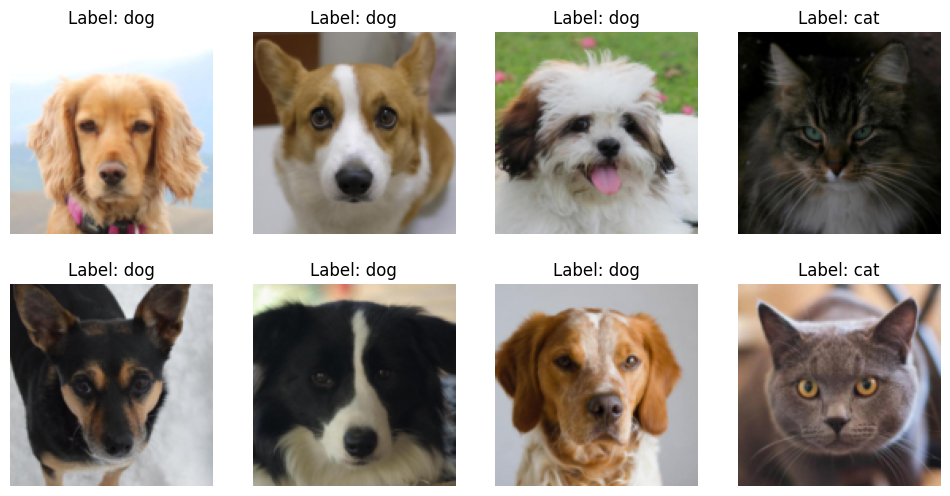

In [4]:
# Setup
train_loader, train_classes = get_dataloaders("./afhq/train")

# Initialize Model (from previous code)
my_model = LatentCVAE(latent_dim=128).to(device)

# 1. Peek at your database
show_batch(train_loader, train_classes)

# 2. (After training) Check transformations
# visualize_transformation(model, data_loader, device)

# Training util functions

In [5]:
import torchvision.models as models

def get_cyclical_beta(epoch, total_epochs, n_cycles=4, ratio=0.5):
    """
    Generates a cyclical beta value.
    n_cycles: Number of times beta goes from 0 to 1.
    ratio: Proportion of each cycle spent increasing (rest of cycle stays at 1.0).
    """
    period = total_epochs / n_cycles
    step = epoch % period
    
    # Calculate the ramp
    if step < period * ratio:
        return step / (period * ratio)
    else:
        return 1.0
    

def latent_loss_function(recon_latents, target_latents, mu, logvar, beta=1.0):
    """
    Computes loss in Latent Space.
    1. MSE: How close is the predicted latent to the VAE's actual latent?
    2. KLD: Regularization for the Conditional VAE.
    """
    # 1. Reconstruction Loss (MSE on Latents)
    # reduction='sum' makes it comparable to the KLD magnitude
    recon_loss = F.mse_loss(recon_latents, target_latents, reduction='sum')
    # recon_loss = F.l1_loss(recon_latents, target_latents, reduction='sum')
    
    # 2. KL Divergence
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return recon_loss + (beta * kld_loss)

In [6]:
def train_epoch(model, dataloader, optimizer, device, epoch, num_epochs):
    """
    model: Your tiny LatentCVAE
    vae: The frozen Stable Diffusion AutoencoderKL
    """
    model.train()
    # We don't need to put VAE in train mode because we never update it
    # vae.eval() is assumed global, but good to be safe
    
    train_loss = 0
    
    # KL Annealing: Start with low beta to encourage reconstruction, then increase
    # Or keep it constant (e.g., 0.001) for Latent Diffusion tasks
    # if epoch < 5:
    #     beta = 0.0
    # else:
    #     # Linearly increase from 0 to 0.00025 over epochs 5 to 15
    #     beta = min(0.00025, (epoch - 5) * (0.00025 / 10))
    beta = get_cyclical_beta(epoch,num_epochs,n_cycles=5)
    
    for batch_idx, (data, labels) in enumerate(dataloader):
        data, labels = data.to(device), labels.to(device)
        
        # --- STEP 1: Get "Ground Truth" Latents from Frozen VAE ---
        with torch.no_grad():
            # Encode pixels to distribution
            posterior = model.pretrained_vae.encode(data).latent_dist
            # Sample (or just take mode) and Scale
            # 0.18215 is CRITICAL for StabilityAI VAEs
            latents = posterior.sample() * 0.18215
        
        # --- STEP 2: Train Your Model ---
        optimizer.zero_grad()
        
        # Forward pass: Your model tries to predict the 'latents' given the 'labels'
        recon_latents, mu, logvar = model(latents, labels)
        
        # Calculate loss against LATENTS, not data/pixels
        loss = latent_loss_function(recon_latents, latents, mu, logvar, beta)
        
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
    avg_loss = train_loss / len(dataloader.dataset)
    return avg_loss

def validate_epoch(model, dataloader, device):
    model.eval()
    val_loss = 0
    
    # We need beta for validation loss calculation to be consistent, usually 1.0 or same as train
    # For validation simple Reconstruction Error (MSE) is often the most important metric
    
    with torch.no_grad():
        for data, labels in dataloader:
            data, labels = data.to(device), labels.to(device)
            
            # --- STEP 1: Get Ground Truth Latents ---
            posterior = model.pretrained_vae.encode(data).latent_dist
            latents = posterior.sample() * 0.18215
            
            # --- STEP 2: Validate Your Model ---
            recon_latents, mu, logvar = model(latents, labels)
            
            # Use same loss function (Latents vs Latents)
            # We fix beta=0.1 here for consistent reporting, or use 1.0
            loss = latent_loss_function(recon_latents, latents, mu, logvar, beta=1)
            
            val_loss += loss.item()
            
    avg_loss = val_loss / len(dataloader.dataset)
    return avg_loss

# Training Loop

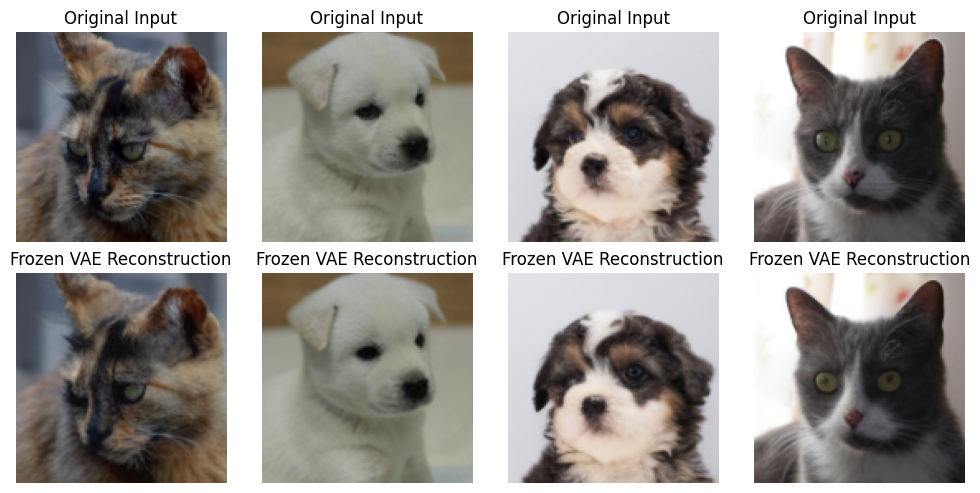

In [7]:
def check_frozen_vae_quality(vae, dataloader, device):
    vae.eval()
    images, _ = next(iter(dataloader))
    images = images.to(device)
    
    # 1. Encode and then immediately Decode using the Frozen VAE
    with torch.no_grad():
        posterior = vae.encode(images).latent_dist
        latents = posterior.sample() * 0.18215
        
        # Unscale and Decode
        reconstructed = vae.decode(latents / 0.18215).sample

    # 2. Visualize
    images = (images / 2 + 0.5).clamp(0, 1).cpu().permute(0, 2, 3, 1).numpy()
    reconstructed = (reconstructed / 2 + 0.5).clamp(0, 1).cpu().permute(0, 2, 3, 1).numpy()
    
    fig, axes = plt.subplots(2, 4, figsize=(10, 5))
    for i in range(4):
        axes[0, i].imshow(images[i])
        axes[0, i].set_title("Original Input")
        axes[0, i].axis('off')
        
        axes[1, i].imshow(reconstructed[i])
        axes[1, i].set_title("Frozen VAE Reconstruction")
        axes[1, i].axis('off')
    plt.tight_layout()
    plt.show()

model = LatentCVAE(latent_dim=256).to(device)
check_frozen_vae_quality(model.pretrained_vae, train_loader, device)

In [8]:
from copy import deepcopy

train_loader, train_classes = get_dataloaders("./afhq/train",transform=aug_transform)
val_loader, val_classes = get_dataloaders("./afhq/val",shuffle=False)

# --- Configuration ---
num_epochs = 40
learning_rate = 1e-3

# Initialize Model and Optimizer
model = LatentCVAE(latent_dim=256).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=num_epochs
)
best_val_loss=np.inf
# --- Main Loop ---
for epoch in range(1, num_epochs + 1):
    # Call training function
    train_loss = train_epoch(model, train_loader, optimizer, device, epoch, num_epochs)
    
    # Call validation function
    val_loss = validate_epoch(model, val_loader, device)
    print(f'Epoch {epoch}: Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')
    scheduler.step(val_loss)
    if val_loss<best_val_loss:
        best_val_loss = val_loss
        print("Saved best model")
        state_dict = deepcopy(model.state_dict())
    
    # Optional: Save model checkpoint
    # torch.save(model.state_dict(), f"cvae_epoch_{epoch}.pth")

Epoch 1: Train Loss: 564.8310 | Val Loss: 534.0034
Saved best model
Epoch 2: Train Loss: 484.4659 | Val Loss: 515.4102
Saved best model
Epoch 3: Train Loss: 481.3903 | Val Loss: 511.7867
Saved best model
Epoch 4: Train Loss: 484.6635 | Val Loss: 508.8890
Saved best model
Epoch 5: Train Loss: 481.7378 | Val Loss: 504.6435
Saved best model
Epoch 6: Train Loss: 475.6683 | Val Loss: 499.6815
Saved best model
Epoch 7: Train Loss: 474.0455 | Val Loss: 497.9361
Saved best model
Epoch 8: Train Loss: 408.5409 | Val Loss: 935.1211
Epoch 9: Train Loss: 433.7416 | Val Loss: 512.2303
Epoch 10: Train Loss: 426.6586 | Val Loss: 484.5010
Saved best model
Epoch 11: Train Loss: 446.3145 | Val Loss: 498.2376
Epoch 12: Train Loss: 446.4204 | Val Loss: 476.8824
Saved best model
Epoch 13: Train Loss: 446.2733 | Val Loss: 481.4055
Epoch 14: Train Loss: 441.9929 | Val Loss: 482.0407
Epoch 15: Train Loss: 436.5629 | Val Loss: 472.3130
Saved best model
Epoch 16: Train Loss: 335.7555 | Val Loss: 1038.7810
Epoch 

# Visualize trained model output

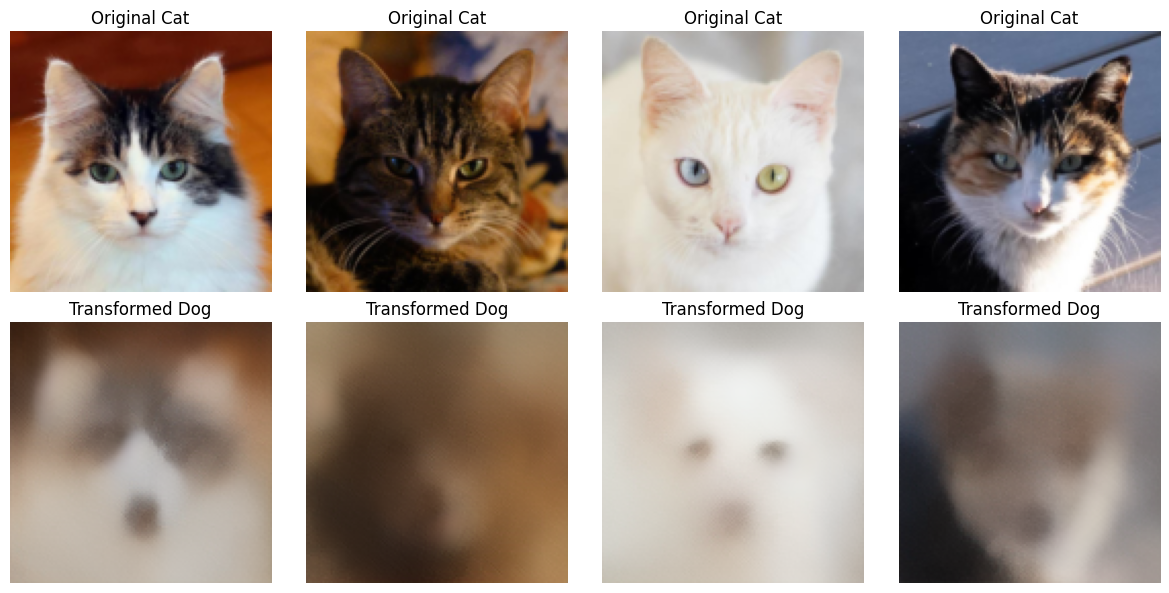

In [12]:
# Load best model
model.load_state_dict(state_dict)
visualize_transformation(model, val_loader, device)

In [10]:
def show_generated_image(model, label, device):
    model.eval()
    with torch.no_grad():
        # 1. Generate random noise (z)
        # Ensure '128' matches the latent_dim you initialized the model with!
        # If you initialized with 256, change this to 256.
        z = torch.randn(1, 256).to(device) 
        y = torch.tensor([label]).to(device)
        
        # 2. Decode to Latents (Your Model)
        # Your model predicts the compressed features (Shape: 1 x 4 x 8 x 8 typically)
        generated_latents = model.decode(z, y)
        
        # 3. Unscale (Reverse the magic number)
        generated_latents = generated_latents / 0.18215
        
        # 4. Decode to Pixels (Frozen VAE)
        # This expands the small latents back to full images
        image = model.pretrained_vae.decode(generated_latents).sample
        
        # 5. Format for Plotting
        # Data is [-1, 1], we need [0, 1] for matplotlib
        image = (image / 2 + 0.5).clamp(0, 1)
        
        # Move to CPU and Permute (Channels First -> Channels Last)
        img = image[0].permute(1, 2, 0).cpu().numpy()
        
        plt.imshow(img)
        plt.title(f"Generated Class {label}")
        plt.axis('off') # Looks cleaner
        plt.show()

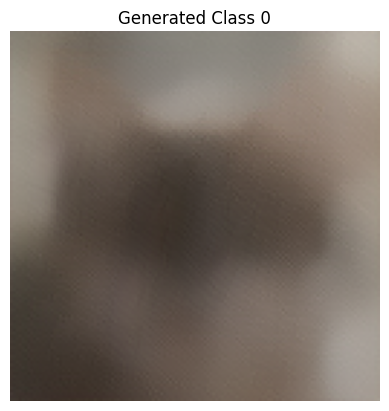

In [30]:
show_generated_image(model, 0, device)